# EDA - Reference

<details>
<summary>Table des Matières</summary>

0. [Données](#0-données)
1. [Distributions par rayon](#1-distributions-par-rayon)
2. [Complétude et qualité](#2-complétude-et-qualité)
3. [Corrélations](#3-corrélations)
4. [Extrêmes restants](#4-extrêmes-restants)
5. [Hypothèses et registre](#5-hypothèses-et-registre)
6. [Synthèse](#6-synthèse)

</details>

In [21]:
#%matplotlib notebook
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats

In [22]:
import sys
import os
from pathlib import Path

# Ajouter src/ au path
ROOT = Path(os.path.abspath("")).parent / "src"
print(ROOT)
sys.path.insert(0, str(ROOT))

c:\Users\Administrateur\Documents\Cours\NutriScope - Projet\Nutriscope_team_delegue\src


In [23]:
from eda import profile_by_pnns_group, figure

# 0. Données

In [ ]:
# TODO: à remplacer
from _commun import charger_propre
df, _ = charger_propre("../data-nutriscope/echantillon_france.csv")

# 1. Distributions par rayon

In [25]:
prof_by_pnns, not_included = profile_by_pnns_group(df)
print(prof_by_pnns)
print(not_included)

                        energy-kcal_100g                                  \
                                 mediane     q25     q75 moyenne       n   
Alcoholic beverages                 49.9   23.75   78.00   97.34    46.0   
Baby foods                          67.0   59.25   88.75  141.27    50.0   
Beverages                           37.0    5.00   54.00   71.40   468.0   
Cereals and potatoes               351.0  256.00  382.25  323.08   612.0   
Composite foods                    158.0  117.00  230.00  176.33   457.0   
Fat and sauces                     304.0  112.75  755.50  411.24   444.0   
Fish Meat Eggs                     191.0  124.00  279.00  216.72   953.0   
Fruits and vegetables               60.0   30.65  227.50  125.25   375.0   
Milk and dairy products            239.0  103.00  342.00  227.16   673.0   
Salty snacks                       500.0  294.25  587.00  438.67   334.0   
Sugary snacks                      421.0  326.00  507.00  405.55  1187.0   

           

## Médianes des sucres par rayon

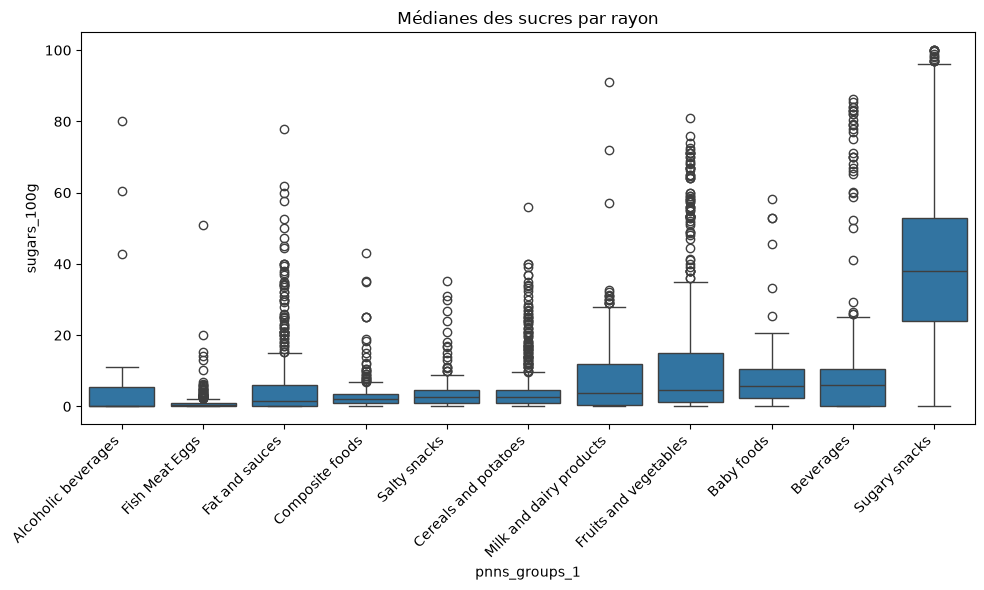

In [26]:
# 1. Calculer la médiane par groupe et trier les catégories
reordered_indexes = df.groupby("pnns_groups_1", observed=True)["sugars_100g"].median().sort_values().index
sugars = df[["sugars_100g"]]

# 2. Transformer la colonne en type catégoriel ordonné selon ces médianes
sugars["pnns_groups_1"] = pd.Categorical(df["pnns_groups_1"], categories=reordered_indexes, ordered=True)

# 3. Tracer directement avec seaborn
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=sugars, x="pnns_groups_1", y="sugars_100g", ax=ax)
ax.set_title("Médianes des sucres par rayon")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
figure(fig, "medianes-sucres-rayon")

## Médianes des sels par rayon (barres)

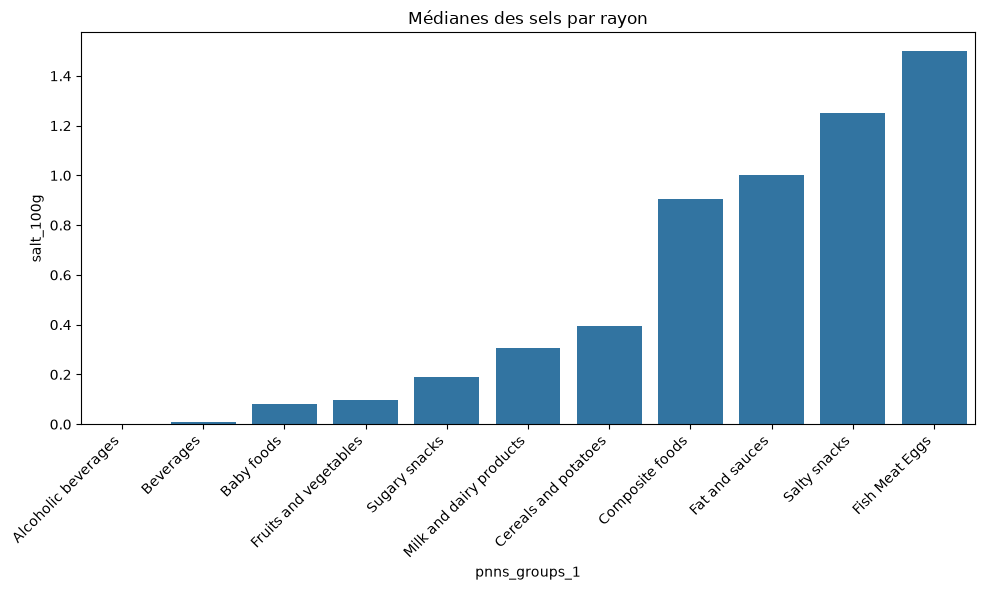

In [27]:
salt = pd.DataFrame(df.groupby("pnns_groups_1", observed=True)["salt_100g"].median().sort_values())

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=salt, x="pnns_groups_1", y="salt_100g", ax=ax)
ax.set_title("Médianes des sels par rayon")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
figure(fig, "medianes-sel-rayon-barres")

## Croisement rayon × grade en %

In [28]:
g = df[df["nutriscore_grade"].isin(list("abcde"))] 
contingency_table = pd.crosstab(g["pnns_groups_1"], g["nutriscore_grade"], normalize="index")
ct_pct = (contingency_table * 100).round(2)
ct_pct

nutriscore_grade,a,b,c,d,e
pnns_groups_1,,,,,
Alcoholic beverages,0.00,50.00,0.00,0.00,50.00
Beverages,6.90,24.40,27.59,17.24,23.87
Cereals and potatoes,33.27,19.79,26.27,16.81,3.85
Composite foods,8.41,15.95,48.28,23.71,3.66
Fat and sauces,6.39,20.64,20.39,15.97,36.61
Fish Meat Eggs,20.04,9.16,13.25,27.37,30.17
Fruits and vegetables,50.29,14.24,16.28,12.50,6.69
Milk and dairy products,5.20,7.24,30.55,45.83,11.18
Salty snacks,9.85,9.85,20.00,29.54,30.77


In [38]:
# NOTE: Calcule directement le V de Cramér en une ligne à partir du tableau croisé
# from scipy.stats import contingency
# cramer_v = contingency.association(contingency_table, method="cramer")

chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape) - 1
cramer_v = np.sqrt(chi2 / (n * min_dim))
print(f"V de Cramer : {cramer_v:.2f}")

V de Cramer : 0.37


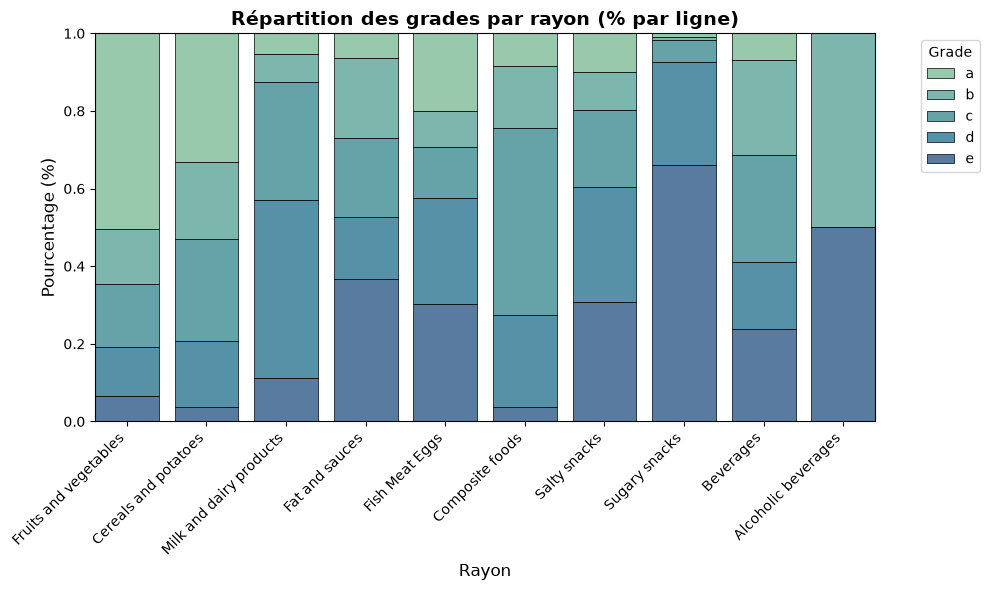

In [37]:
plt.figure(figsize=(10, 6))
ax = sns.histplot(
    data=g.sort_values("nutriscore_grade"),
    x="pnns_groups_1",
    hue="nutriscore_grade",
    multiple="fill",
    stat="percent",
    discrete=True,
    shrink=0.8,
    palette="crest",
    edgecolor="black",
    linewidth=0.5,
)

plt.title(
    "Répartition des grades par rayon (% par ligne)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Rayon", fontsize=12)
plt.ylabel("Pourcentage (%)", fontsize=12)

# Déplacement propre de la légende hors du graphique via Seaborn
sns.move_legend(ax, loc="upper left", bbox_to_anchor=(1.05, 1), title="Grade")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

figure(ax.figure, "repartition-grades-rayon")

# 2. Complétude et qualité

In [ ]:
def completeness_by_group(df, group, column, min_n=20):
    pass

In [ ]:
def business_inconsistency(df):
    pass

# 3. Corrélations

# 4. Extrêmes restants

# 5. Hypothèses et registre

# 6. Synthèse

> Le rayon « unknown » est **écarté des comparaisons par rayon** et signalé dans la synthèse (part, complétude) : il représente plus de la moitié de l'extrait complet